<h2 style='color:blue' align='center'>RiskProof AI: KNN Classification on Fraud Oracle</h2>

This notebook adapts the KNN tutorial structure to the `fraud_oracle.csv` dataset for RiskProof AI.
It loads the data, cleans it, applies one-hot encoding, trains KNN with different `k` values, selects the best accuracy, and shows predictions and a confusion matrix.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle
import joblib

_ = (pd, np, plt, sns, train_test_split, GridSearchCV, StandardScaler, KNeighborsClassifier, accuracy_score, confusion_matrix, classification_report, pickle, joblib)

## 1. Load Dataset

In [ ]:
df = pd.read_csv('fraud_oracle.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## 2. Clean Data

In [ ]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())

print('\nMissing values before:', df.isnull().sum().sum())
df = df.dropna()
print('Missing values after:', df.isnull().sum().sum())
print('Cleaned shape:', df.shape)

Duplicates before: 0


Duplicates after: 0

Missing values before: 0
Missing values after: 0
Cleaned shape: (15420, 33)


## 2.1 Exploratory Data Analysis (EDA)
In this section, we visualize the distribution of fraud cases across key features to understand the dataset structure, similar to how we visualized Sepal and Petal dimensions in the Iris dataset.

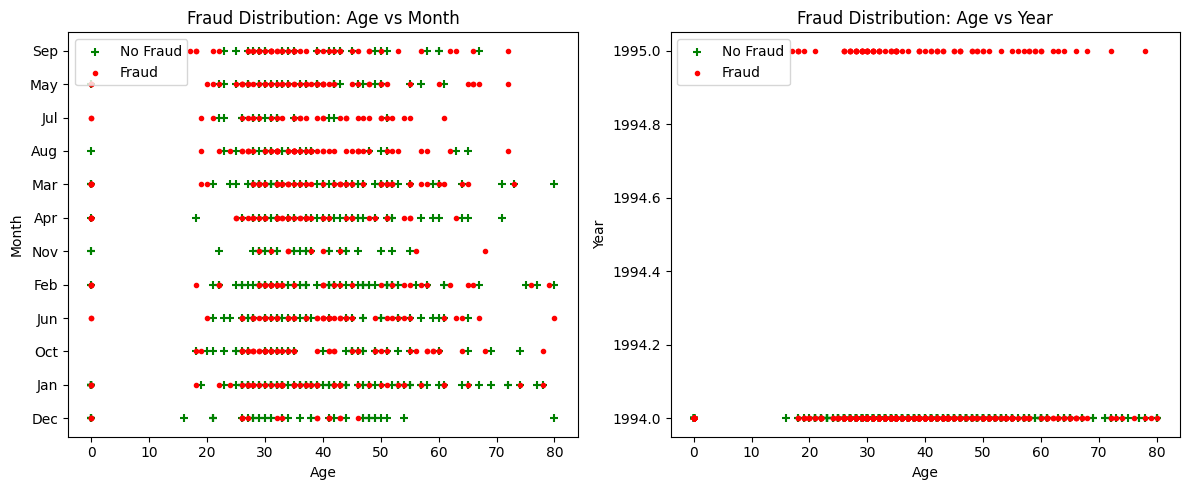

In [4]:
# Ensure df is loaded (in case the previous cell wasn't executed in this session)
try:
    df_no_fraud = df[df['FraudFound_P'] == 0]
    df_fraud = df[df['FraudFound_P'] == 1]
except NameError:
    df = pd.read_csv('fraud_oracle.csv')
    df_no_fraud = df[df['FraudFound_P'] == 0]
    df_fraud = df[df['FraudFound_P'] == 1]

plt.figure(figsize=(12, 5))

# Visualization 1: Age vs Month
plt.subplot(1, 2, 1)
plt.scatter(df_no_fraud['Age'].head(500), df_no_fraud['Month'].head(500), color='green', marker='+', label='No Fraud')
plt.scatter(df_fraud['Age'].head(500), df_fraud['Month'].head(500), color='red', marker='.', label='Fraud')
plt.xlabel('Age')
plt.ylabel('Month')
plt.title('Fraud Distribution: Age vs Month')
plt.legend()

# Visualization 2: Age vs Year
plt.subplot(1, 2, 2)
plt.scatter(df_no_fraud['Age'].head(500), df_no_fraud['Year'].head(500), color='green', marker='+', label='No Fraud')
plt.scatter(df_fraud['Age'].head(500), df_fraud['Year'].head(500), color='red', marker='.', label='Fraud')
plt.xlabel('Age')
plt.ylabel('Year')
plt.title('Fraud Distribution: Age vs Year')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Feature Engineering and Split

In [ ]:
X_raw = df.drop('FraudFound_P', axis=1)
y = df['FraudFound_P']

categorical_cols = X_raw.select_dtypes(include=['object', 'string']).columns
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
print('Features shape after encoding:', X.shape)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Features shape after encoding: (15420, 124)


Train shape: (12336, 124)
Test shape: (3084, 124)


## 4. Train and Tune KNN

In [ ]:
base_knn = KNeighborsClassifier(n_neighbors=10)
base_knn.fit(X_train, y_train)
base_accuracy = base_knn.score(X_test, y_test)
print('Base KNN accuracy (k=10):', base_accuracy)

Base KNN accuracy (k=10): 0.9396887159533074


In [ ]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_accuracy = best_model.score(X_test, y_test)
best_k = best_model.get_params()['n_neighbors']

print('Best parameters:', grid_search.best_params_)
print('Best k:', best_k)
print('Best accuracy:', best_accuracy)

Best parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best k: 11
Best accuracy: 0.9400129701686122


### 4.1 Extended Hyperparameter Tuning
We will now use a broader range of neighbors and different distance metrics (Manhattan vs Euclidean) to find the most accurate configuration for the RiskProof AI model.

In [9]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Ensure data is split if not already in memory
try:
    _ = X_train.shape
except NameError:
    X_raw = df.drop('FraudFound_P', axis=1)
    y = df['FraudFound_P']
    categorical_cols = X_raw.select_dtypes(include=['object', 'string']).columns
    X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Defining parameters for tuning
param_grid_extended = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Run extended grid search
grid_search_best = GridSearchCV(KNeighborsClassifier(), param_grid_extended, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_best.fit(X_train, y_train)

print('Optimal Parameters Found:', grid_search_best.best_params_)
print('Highest Cross-Validation Accuracy:', grid_search_best.best_score_)

# Update global variables for evaluation
best_model = grid_search_best.best_estimator_
best_accuracy = best_model.score(X_test, y_test)
best_k = best_model.get_params()['n_neighbors']

Optimal Parameters Found: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Highest Cross-Validation Accuracy: 0.9404183520690292


In [10]:
# Perform prediction using the best model found
y_pred = best_model.predict(X_test)
print('Sample predictions (Top 10):', y_pred[:10])

cm = confusion_matrix(y_test, y_pred)
print('\nConfusion matrix:\n', cm)

Sample predictions (Top 10): [0 0 0 0 0 0 0 0 0 0]

Confusion matrix:
 [[2897    2]
 [ 184    1]]


## 5. Evaluate and Save Model

Final model accuracy: 0.9400129701686122

Classification report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.50      0.01      0.01       185

    accuracy                           0.94      3084
   macro avg       0.72      0.50      0.49      3084
weighted avg       0.91      0.94      0.91      3084



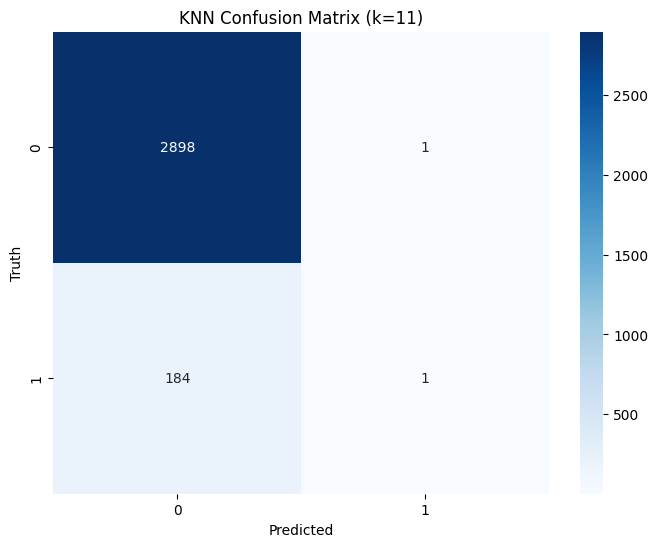

In [ ]:
print('Final model accuracy:', best_accuracy)
print('\nClassification report:\n', classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title(f'KNN Confusion Matrix (k={best_k})')
plt.show()

In [ ]:
if hasattr(best_model, 'predict_proba'):
    fraud_probabilities = best_model.predict_proba(X_test)[:, 1]
    risk_scores = fraud_probabilities * 100
    risk_labels = np.where(risk_scores >= 50, 'High-risk incident', 'Low-risk incident')
    print('Sample risk scores:', np.round(risk_scores[:10], 2).tolist())
    print('Sample risk labels:', risk_labels[:10].tolist())

with open('riskproof_knn.pkl', 'wb') as f:
    pickle.dump(best_model, f)

joblib.dump(best_model, 'riskproof_knn.joblib')
print('Saved model files: riskproof_knn.pkl and riskproof_knn.joblib')

Sample risk scores: [0.0, 0.0, 27.27, 0.0, 0.0, 18.18, 0.0, 0.0, 18.18, 9.09]
Sample risk labels: ['Low-risk incident', 'Low-risk incident', 'Low-risk incident', 'Low-risk incident', 'Low-risk incident', 'Low-risk incident', 'Low-risk incident', 'Low-risk incident', 'Low-risk incident', 'Low-risk incident']
Saved model files: riskproof_knn.pkl and riskproof_knn.joblib
